In [1]:
# This is from Will's tutorial notebook
# It has less helpful text, but can be used, step by step, to produce the yaml, fits, and pickle files for each flight

In [2]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
gbosite=si.Site('../metadata/WLC_config_roof.npz')

In [3]:
# Define any channels, etc, and directories for this flight analysis

#Epols = [0,3,4,7,9,10,12,14]
#Npols = [1,2,5,6,8,11,13,15]



#config_directory="  "
maindir = '/hirax/DNS_freespace/yale_visit_april_2025/'
dronedir = maindir+'drone_flight_records/'
crmap = [7,8,9] # channel maps: crossmap = [7,8,9]

f_ind = 319 
freqs = np.arange(800,400,-400./1024)
gfinds = np.arange(255,385)
print(freqs[f_ind])

675.390625


In [4]:
###################
#### FUNCTIONS ####
###################

## 1. Read in and use yaml file


In [5]:
with open('../metadata/DNS_WL_flights_forscripts.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]


for f in np.arange(0,len(flights)):
    print(f, descrip[f], flights[f])

# 0 (manual) won't work, the drone file had something funny done to it for units


0 manual Apr-12th-2025-03-19PM-Flight-Airdata.csv
1 0.1mps Apr-12th-2025-03-27PM-Flight-Airdata.csv
2 1mps Apr-12th-2025-03-50PM-Flight-Airdata.csv
3 2.5mps Apr-12th-2025-03-58PM-Flight-Airdata.csv
4 5mps Apr-12th-2025-04-03PM-Flight-Airdata.csv


In [6]:
# choose flight
# airdata files are not very easily subscriptable, 
# cluge for now by knowing which flight order is in the yaml

# The manual flight won't work, the drone files have been converted
# to SI units directly

f = 2

fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]

# define directories

datadir = maindir+'/'+cdat
gaindir = maindir+'manual_and_0.1_pass_digital_gains/'
dronedir = maindir+'drone_flight_records/'
print(fly, documents["flight_info"]["desc"][f], cdat)


Apr-12th-2025-03-50PM-Flight-Airdata.csv 1mps 20250412T194037Z_WVUc52/corr/20250412T194134Z/


Initializing drone data via Airdata.csv routine: Apr-12th-2025-03-50PM-Flight-Airdata.csv
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-04-12 19:53:55.900000+00:00 2025-04-12 19:57:01+00:00


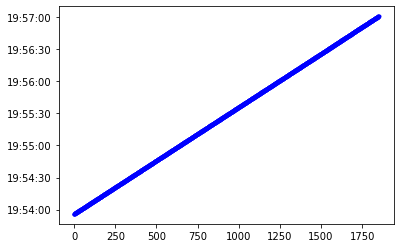

plotting drone coordinates for all time samples:
overplotting drone coordinates for t_cut samples: [0:-1]


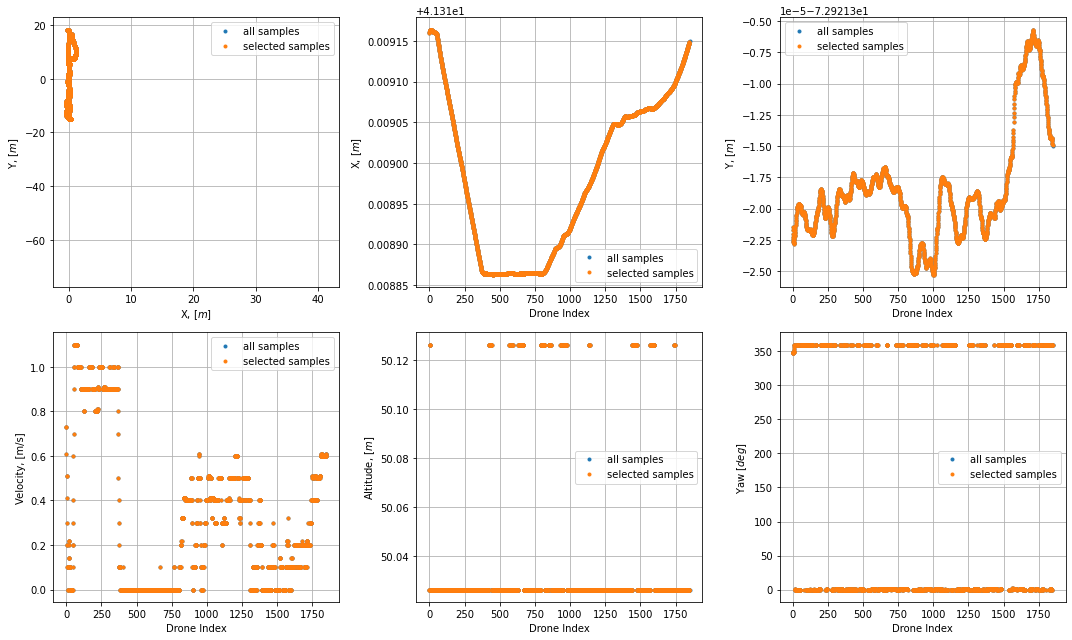

In [7]:
dronetest0825=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronetest0825.t_arr_datetime[0], dronetest0825.t_arr_datetime[-1])

plt.plot(dronetest0825.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronetest0825,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

start time:  2026-02-11 10:41:20.373778
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/yale_visit_april_2025//20250412T194037Z_WVUc52/corr/20250412T194134Z/
  --> Arrays initialized with shape (134, 256, 1024, 2)
Assigning array values by reading in data files:
  --> Loading File: 0133/0133
  --> Finished. Reshaping arrays.
end time:  2026-02-11 10:41:42.924572


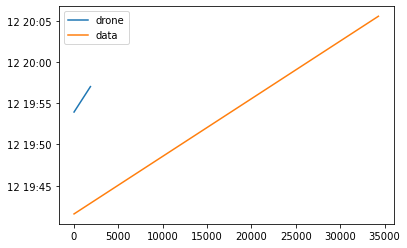

In [8]:
## Combine drone and correlator data
print('start time: ', datetime.datetime.now())
if str(fmax) != 'None':# 
    corrtest0825=corr.Corr_Data(Data_Directory=datadir,
                            Gain_Directory=gaindir,site_class=gbosite,use_ctime=True,
                            crossmap=crmap,Data_File_Index=np.arange(0,int(fmax)))
else:
    corrtest0825=corr.Corr_Data(Data_Directory=datadir,
                            Gain_Directory=gaindir,site_class=gbosite,use_ctime=True,
                            crossmap=crmap)
#

    
print('end time: ', datetime.datetime.now())

# putting checks in one cell now that I know I've mostly figured out the flight/corr file correspondence
# This checks I copied and pasted ok :)

## plot their datetime arrays to check overlap:

plot(dronetest0825.t_arr_datetime,label='drone')
plot(corrtest0825.t_arr_datetime,label='data')
legend()


# 2. Match drone and correlator data together, and plot a few frequencies

In [9]:


concatdata=concat.CONCAT(CORRDATCLASS=corrtest0825,DRONEDATCLASS=dronetest0825,\
                             load_yaml=False,traceback=False,save_traceback=False)
#concattest0825=concat.CONCAT(CORRDATCLASS=corrtest0825,DRONEDATCLASS=dronetest0825,load_yaml=True,
#                             traceback=False,save_traceback=False)


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/axes/_axes.py:4263: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


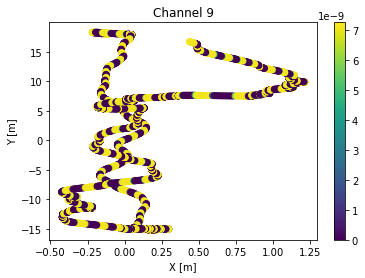

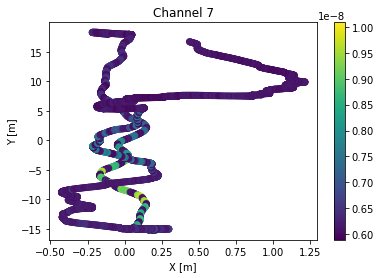

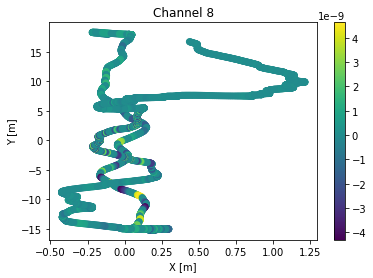

34304 34304


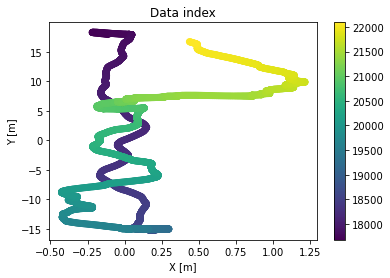

/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


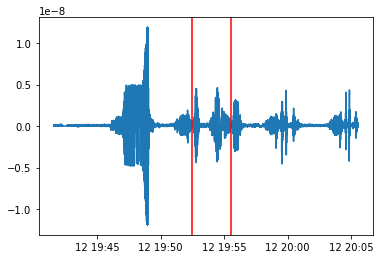

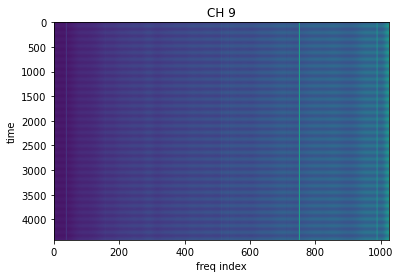

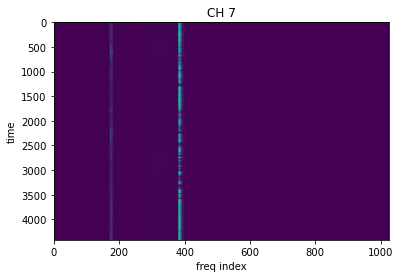

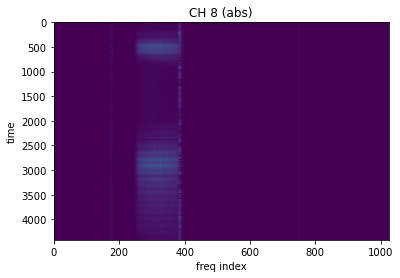

In [10]:
plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
            c=concatdata.V_cross[:,f_ind,2])
plt.colorbar()
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Channel 9')
plt.show()

plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
            c=concatdata.V_cross[:,f_ind,0])
plt.colorbar()
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Channel 7')
plt.show()

plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
            c=concatdata.V_cross[:,f_ind,1])
plt.colorbar()
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Channel 8')
plt.show()

print(len(concatdata.V_cross[:,f_ind,2]),len(concatdata.drone_xyz_LC_interp[:,1]))

plt.scatter(concatdata.drone_xyz_LC_interp[:,0],
            concatdata.drone_xyz_LC_interp[:,1],c=np.arange(0,len(concatdata.drone_xyz_LC_interp[:,1])))
plt.colorbar()
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Data index')
plt.show()


plt.plot(concatdata.t_arr_datetime,concatdata.V_cross[:,f_ind,1])
plt.axvline(concatdata.t_arr_datetime[tclb],color='red')
plt.axvline(concatdata.t_arr_datetime[tcub],color='red')
plt.show()

plt.imshow(concatdata.V_cross[tclb:tcub,:,2].real,aspect='auto')
plt.xlabel('freq index')
plt.ylabel('time')
plt.title('CH 9')
plt.show()

plt.imshow(concatdata.V_cross[tclb:tcub,:,0].real,aspect='auto')
plt.xlabel('freq index')
plt.ylabel('time')
plt.title('CH 7')
plt.show()

plt.imshow(abs(concatdata.V_cross[tclb:tcub,:,1]),aspect='auto')
plt.xlabel('freq index')
plt.ylabel('time')
plt.title('CH 8 (abs)')
plt.show()


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/axes/_axes.py:4263: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


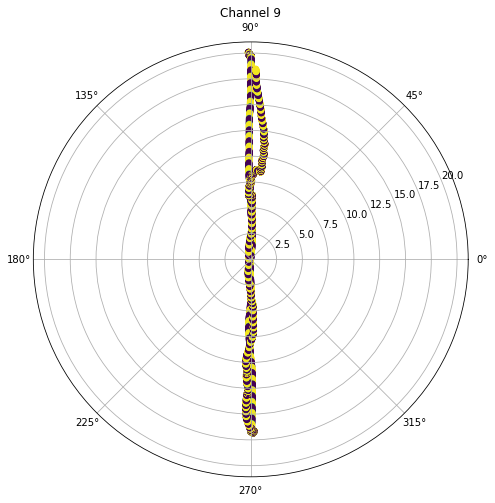

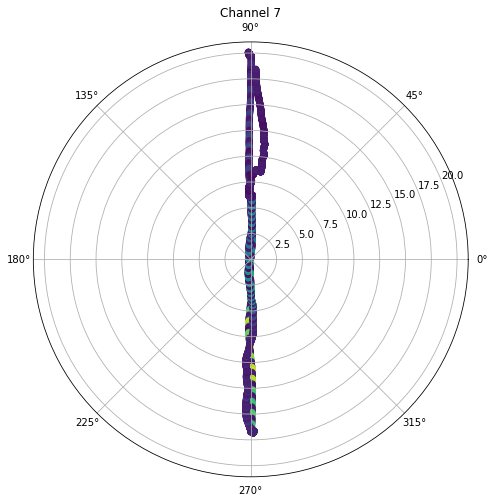

<ipython-input-11-3ff06e773ca4>:19: RuntimeWarning: divide by zero encountered in log10
  c=10*np.log10(concatdata.V_cross[:,f_ind,1]))
<ipython-input-11-3ff06e773ca4>:19: RuntimeWarning: invalid value encountered in multiply
  c=10*np.log10(concatdata.V_cross[:,f_ind,1]))


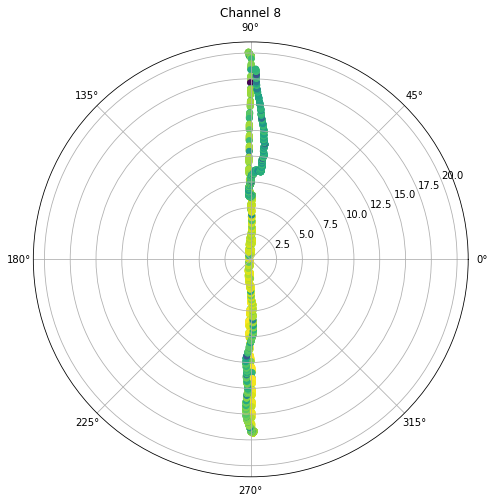

In [11]:
fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(projection='polar')
ax.scatter(concatdata.drone_rpt_interp[:,1],np.degrees(concatdata.drone_rpt_interp[:,2]),
           c=concatdata.V_cross[:,f_ind,2])
plt.title('Channel 9')
plt.show()


fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(projection='polar')
ax.scatter(concatdata.drone_rpt_interp[:,1],np.degrees(concatdata.drone_rpt_interp[:,2]),
           c=10*np.log10(concatdata.V_cross[:,f_ind,0]))
plt.title('Channel 7')
plt.show()

fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(projection='polar')
ax.scatter(concatdata.drone_rpt_interp[:,1],np.degrees(concatdata.drone_rpt_interp[:,2]),
           c=10*np.log10(concatdata.V_cross[:,f_ind,1]))
plt.title('Channel 8')
plt.show()



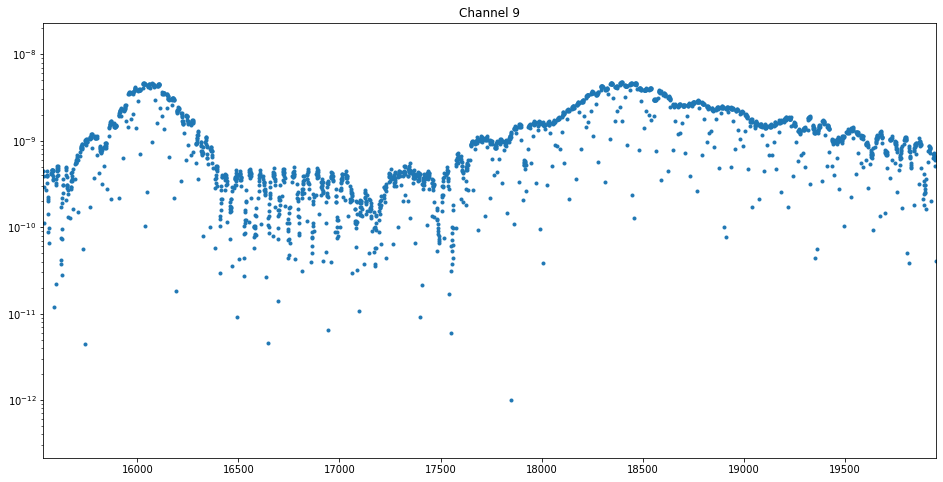

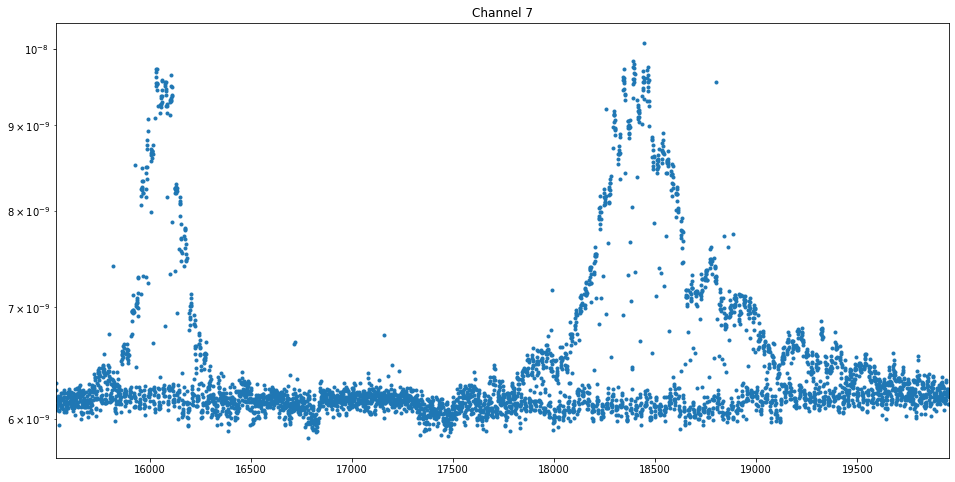

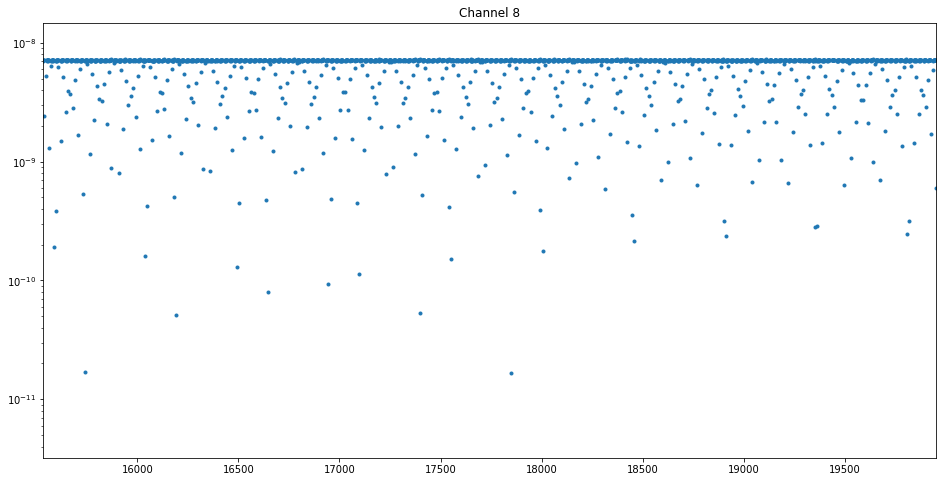

In [12]:
## Let's find the time bounds for a central transit, and examine those bounds when we solve for the source pulses:

# crosspol
fig=figure(figsize=(16,8))
plt.semilogy(concatdata.t_index[:],abs(concatdata.V_cross[:,f_ind,1]),'.')
plt.xlim(tclb,tcub)
plt.title('Channel 9')
plt.show()

# co pol
fig=figure(figsize=(16,8))
plt.semilogy(concatdata.t_index[:],abs(concatdata.V_cross[:,f_ind,0]),'.')
plt.xlim(tclb,tcub)
plt.title('Channel 7')
plt.show()

# ref
fig=figure(figsize=(16,8))
plt.semilogy(concatdata.t_index[:],abs(concatdata.V_cross[:,f_ind,2]),'.')
plt.xlim(tclb,tcub)
plt.title('Channel 8')
plt.show()

## So we've identified time bounds where we can see the pulsing source transit!
    ## Infact, I think we are seeing a sidelobe on channel 1!
    ## Let's see if we can extract the on/off indices...

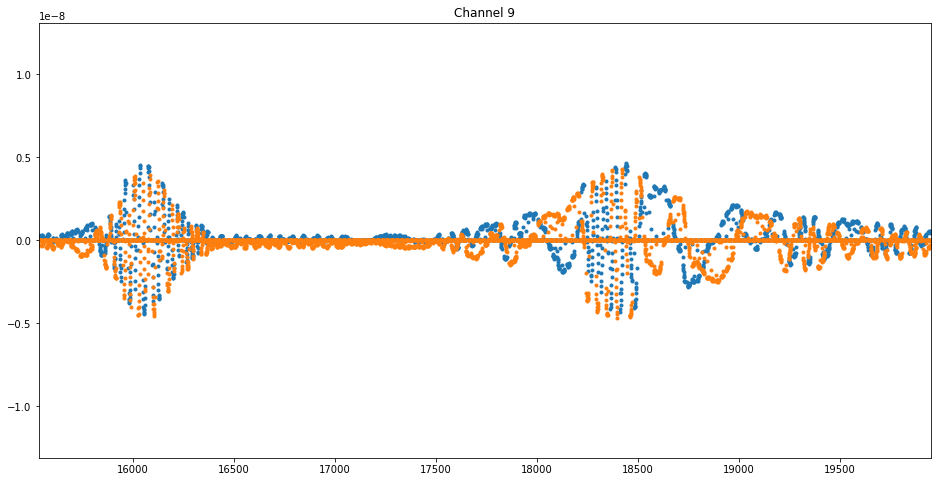

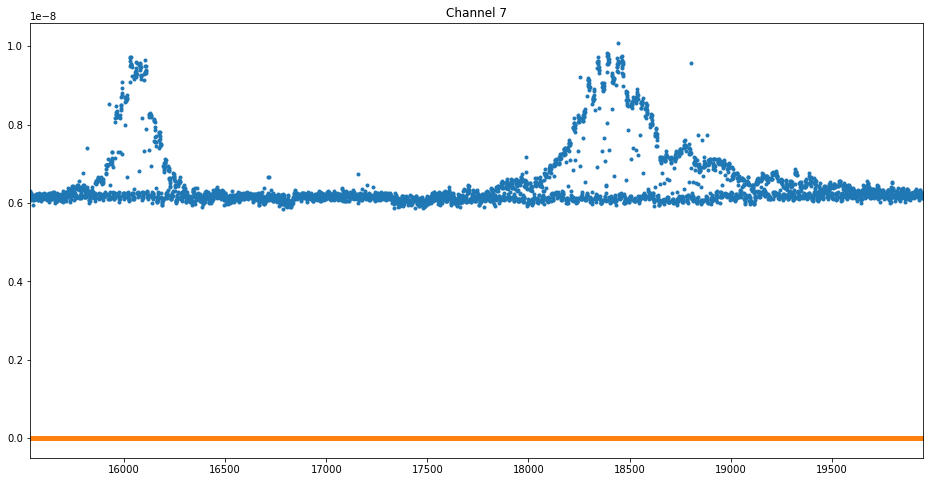

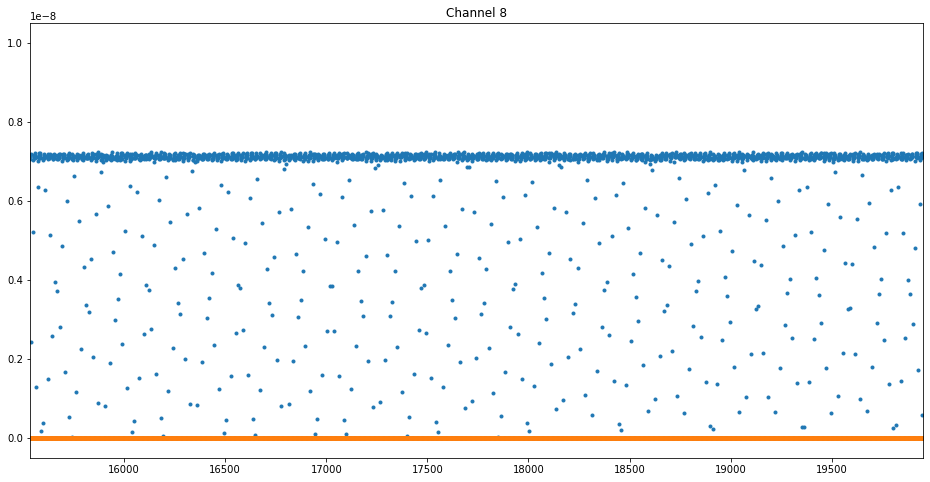

In [13]:
# crosscorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].real,'.')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].imag,'.')
plt.xlim(tclb,tcub)
plt.title('Channel 9')
plt.show()

# autocorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,0].real,'.')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,0].imag,'.')
plt.xlim(tclb,tcub)
plt.title('Channel 7')
plt.show()

# ref
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,2].real,'.')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,2].imag,'.')
plt.xlim(tclb,tcub)
plt.title('Channel 8')
plt.show()

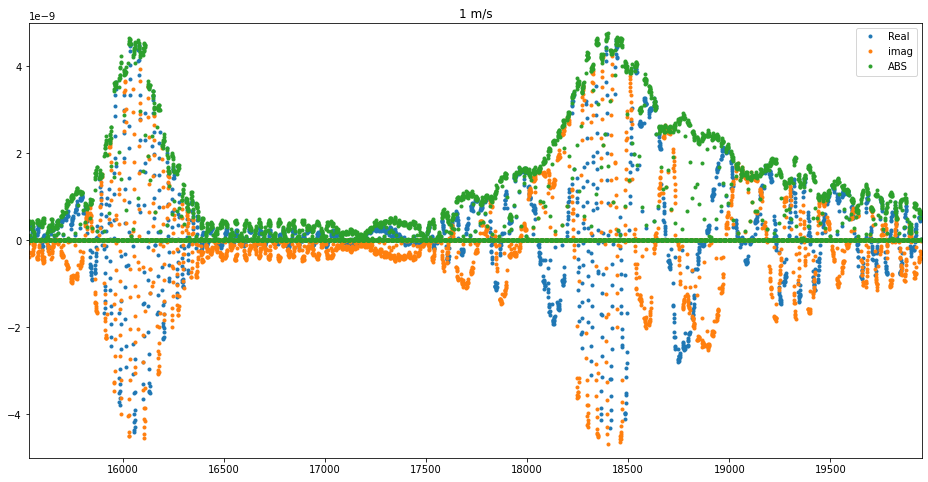

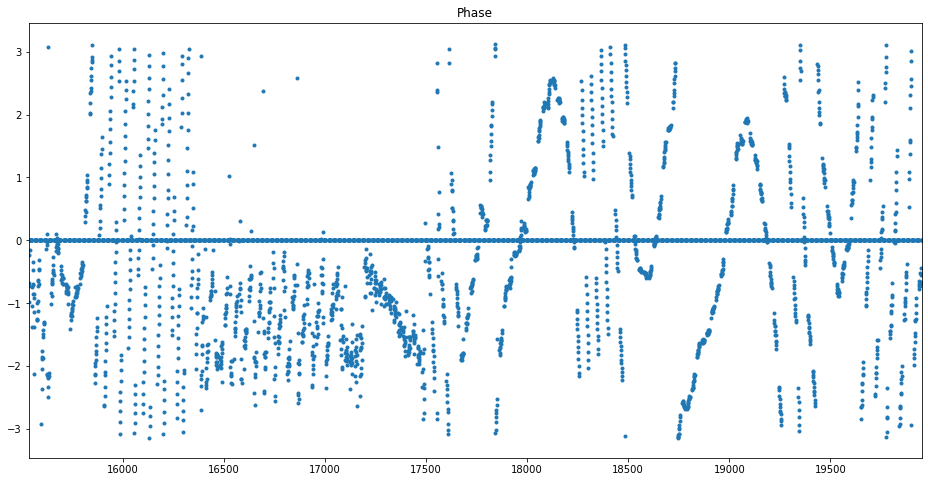

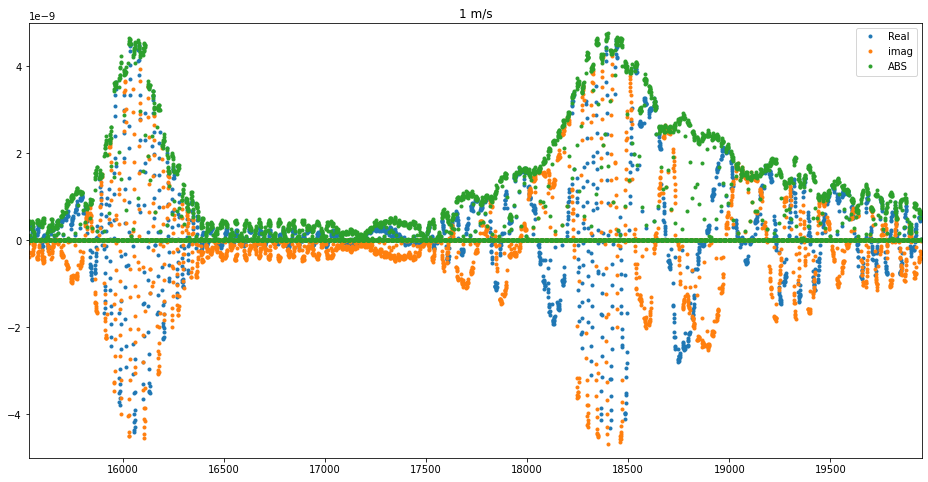

In [14]:
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(concatdata.t_index[:],np.abs(concatdata.V_cross[:,f_ind,1]),'.',label='ABS')
plt.xlim(tclb,tcub)
plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],np.angle(concatdata.V_cross[:,f_ind,1]),'.')
plt.xlim(tclb,tcub)
plt.title('Phase')
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.V_cross[:,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(np.abs(concatdata.V_cross[:,f_ind,1]),'.',label='ABS')
plt.xlim(tclb,tcub)
plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

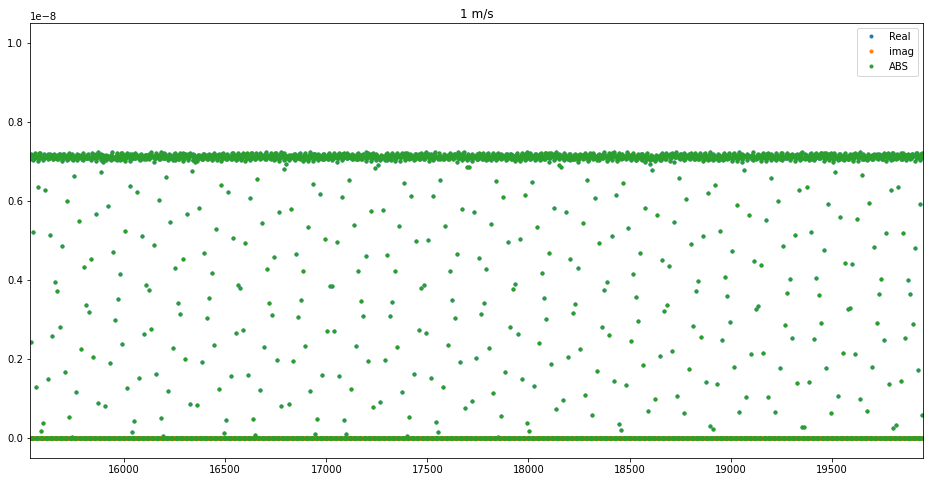

In [15]:
i = 1
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V[:,f_ind,i].real,'.',label='Real')
plt.plot(concatdata.t_index[:],concatdata.V[:,f_ind,i].imag,'.',label='imag')
plt.plot(concatdata.t_index[:],np.abs(concatdata.V[:,f_ind,i]),'.',label='ABS')
plt.xlim(tclb,tcub)
#plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

## 3. Extract on/off/span pulses

In [16]:
## OBJECTIVE 5A: concat Function: Extract_Source_Pulses

## Let's use the Extract_Source_Pulses function:
    # The Period and Dutycycle options are known beforehand, and given in microseconds.
    # The t_bounds option just determines the plot bounds, not the solving routine.
## Fortunately, these parameters are loaded from the config, so we don't have to wait for the solver to run.
    ## The returned t_delta_pulse parameter will be given in seconds.
    ## In the verification plot, we should see the following points plotted:
        # orange_o = inds_off  = times when the source is off
        # blue_o   = inds_on   = times when the source is on and broadcasting
        # green_x  = inds_span = times where the behavior changes during the integration period (omit always!)
    ## The print statements shows the list of indices that appear in more than one of on/off/span.
        ## If they are all empty lists [], then there is no overlap which is a good thing.


print('start time: ', datetime.datetime.now())
concatdata.Extract_Source_Pulses(Period=1e6,Dutycycle=0.5e6,t_bounds=[tclb,tcub],f_ind=f_ind,
                                 use_ref_channel=1)

print('end time: ', datetime.datetime.now())

start time:  2026-02-11 10:41:50.236480
PR MAX SOMETHING PER CHANNEL:  0 -0.7739999999999998
PR MAX SOMETHING PER CHANNEL:  1 -0.7749999999999998
end time:  2026-02-11 10:43:45.899568


15693 2911 15700


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


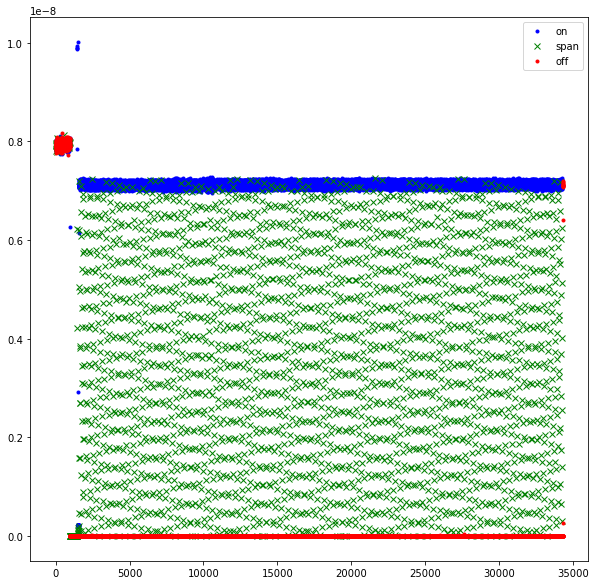

In [17]:
# aside to look at the span, on, and off indices in more detail
chind = 2
t_cut = concatdata.inds_on
t_span = concatdata.inds_span
t_off = concatdata.inds_off
print(len(t_cut),len(t_span),len(t_off))

plt.figure(1,figsize=(10,10))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on')
plt.plot(concatdata.t_index[t_span],concatdata.V_cross[t_span,f_ind,chind],'gx',label='span')
plt.plot(concatdata.t_index[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off')
plt.legend()
#plt.xlim(10000,10050)
plt.show()

/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


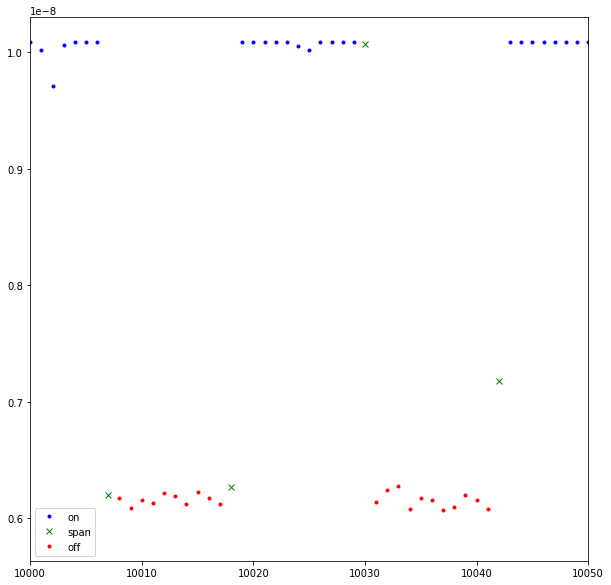

/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


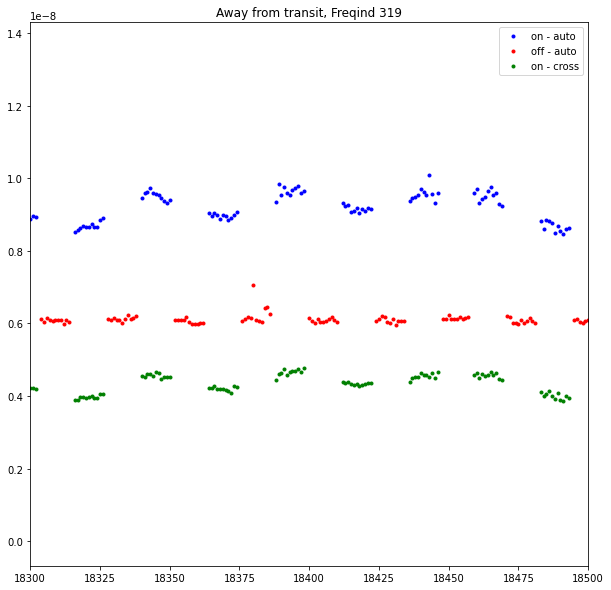

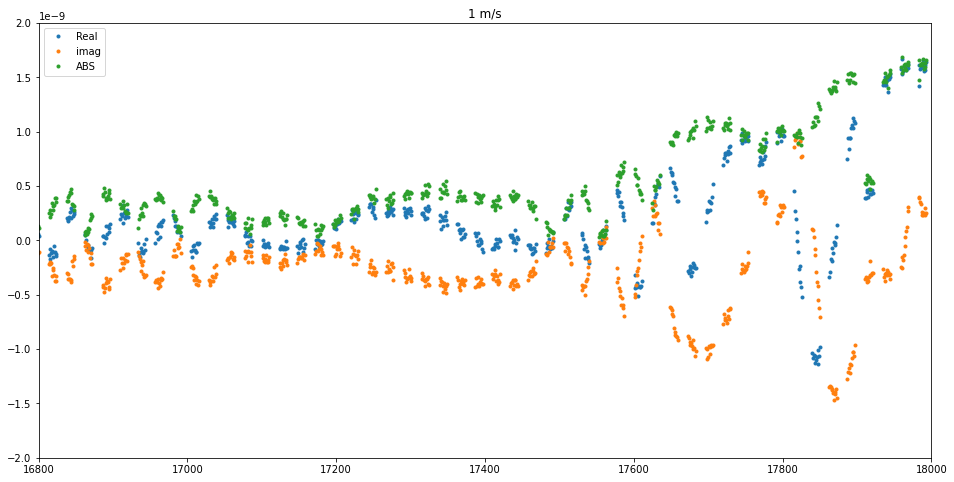

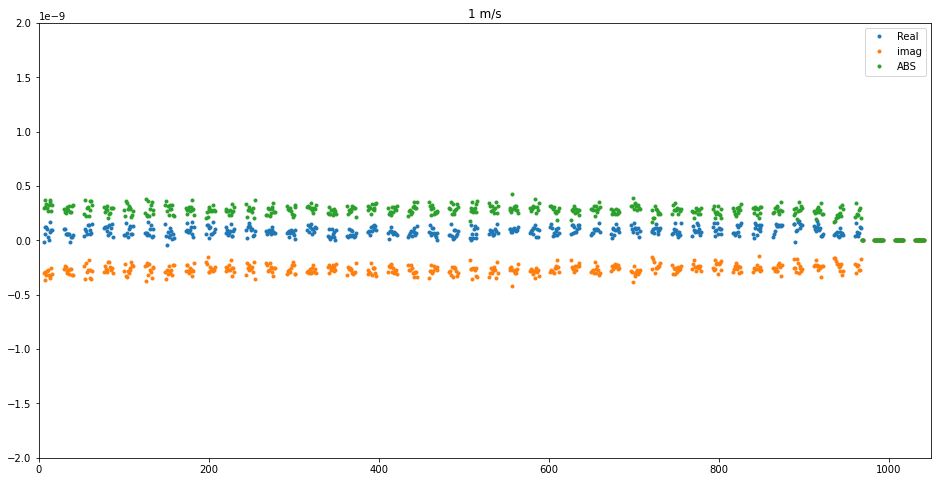

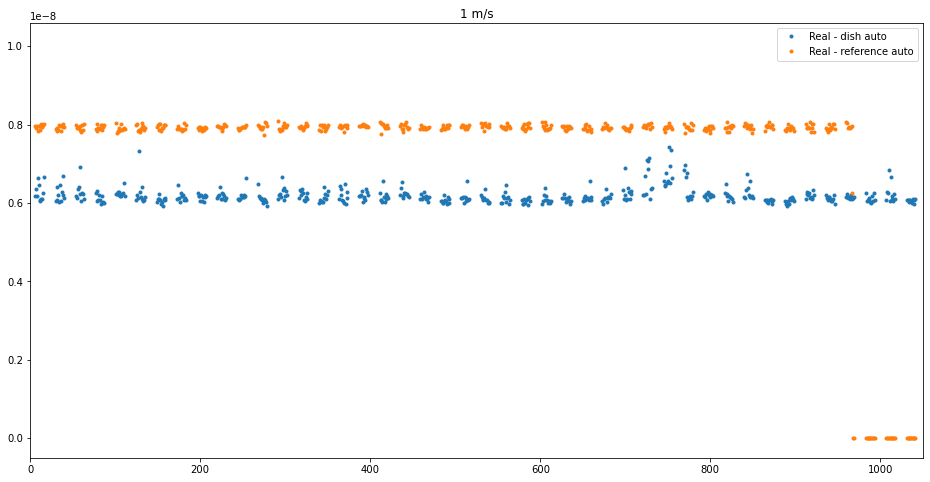

In [66]:
chind = 0
plt.figure(1,figsize=(10,10))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on')
plt.plot(concatdata.t_index[t_span],concatdata.V_cross[t_span,f_ind,chind],'gx',label='span')
plt.plot(concatdata.t_index[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off')
plt.legend()
plt.xlim(10000,10050)
plt.show()

plt.figure(1,figsize=(10,10))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on - auto')
plt.plot(concatdata.t_index[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off - auto')
plt.plot(concatdata.t_index[t_cut],abs(concatdata.V_cross[t_cut,f_ind,1]),'g.',label='on - cross')
plt.legend()
plt.xlim(18300,18500)
#plt.xlim(16800,18000)
plt.title('Away from transit, Freqind '+str(f_ind))
#plt.ylim(0.4E-8,0.8E-8)
plt.show()

# Lets look at the imaginary component in this time range too

fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,1].imag,'.',label='imag')
plt.plot(concatdata.t_index[t_cut],np.abs(concatdata.V_cross[t_cut,f_ind,1]),'.',label='ABS')
plt.xlim(16800,18000)
plt.ylim(-2E-9,2E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,1].imag,'.',label='imag')
plt.plot(concatdata.t_index[t_cut],np.abs(concatdata.V_cross[t_cut,f_ind,1]),'.',label='ABS')
plt.xlim(0,1050)
plt.ylim(-2E-9,2E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

chind = 0 # reference
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind].real,'.',label='Real - dish auto')

chind = 2 # reference
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind].real,'.',label='Real - reference auto')
plt.xlim(0,1050)
#plt.ylim(-2E-9,2E-9)
plt.title('1 m/s')
plt.legend()
plt.show()




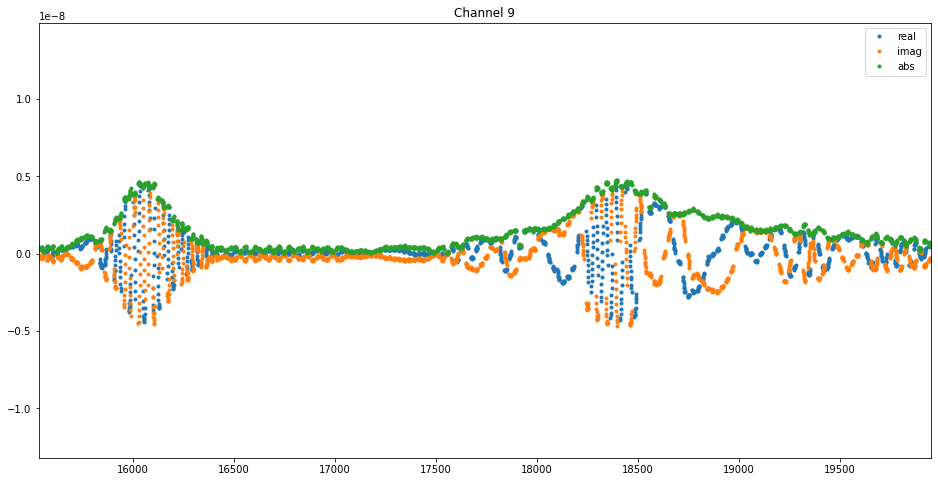

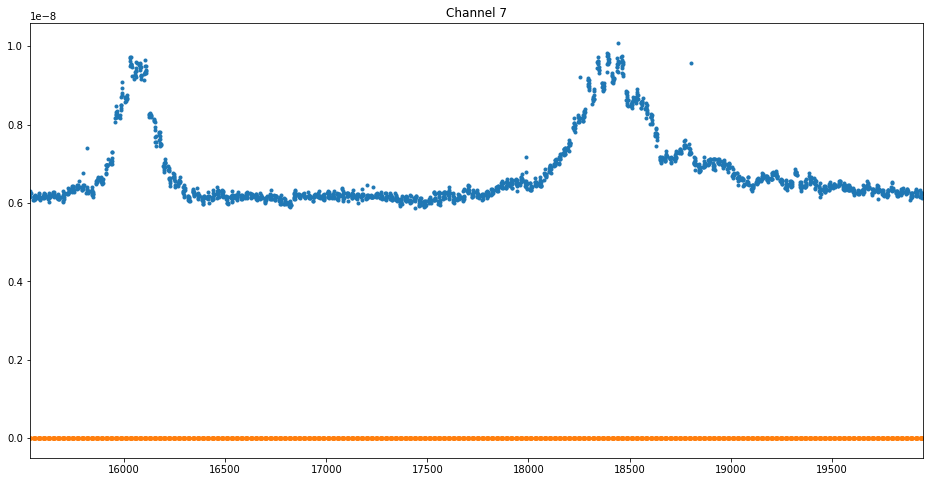

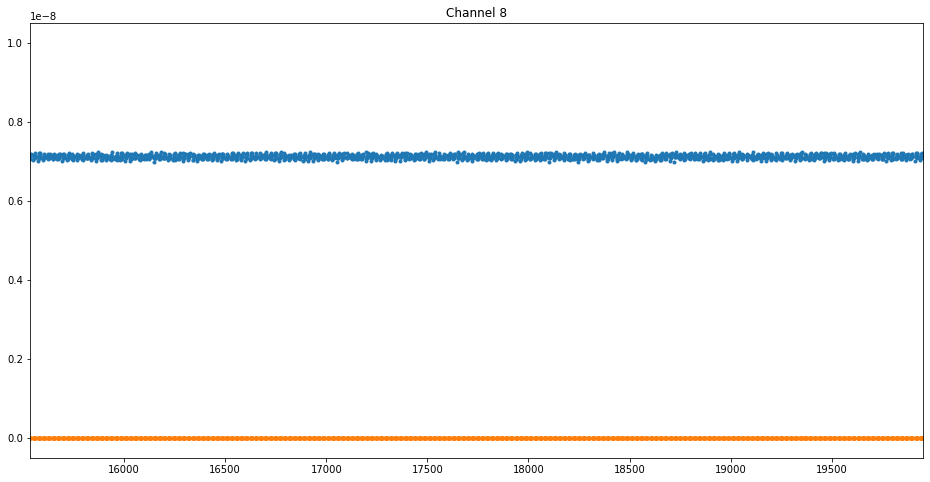

In [67]:
#f_ind = 300
# crosscorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,1].real,'.',label='real')
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,1].imag,'.',label='imag')
plt.plot(concatdata.t_index[t_cut],np.abs(concatdata.V_cross[t_cut,f_ind,1]),'.',label='abs')
plt.xlim(tclb,tcub)
plt.legend()
plt.title('Channel 9')
plt.show()

# autocorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,0].real,'.')
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,0].imag,'.')
plt.xlim(tclb,tcub)
plt.title('Channel 7')
plt.show()

# ref
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,2].real,'.')
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,2].imag,'.')
plt.xlim(tclb,tcub)
plt.title('Channel 8')
plt.show()

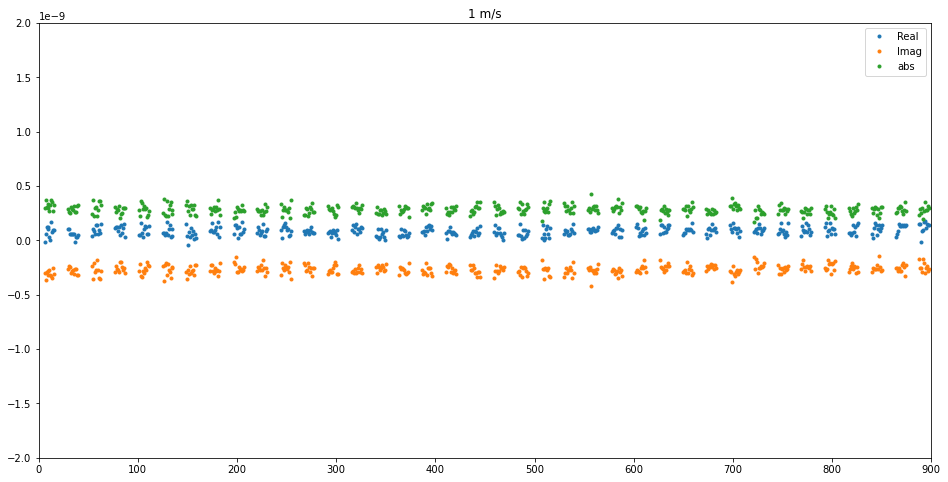

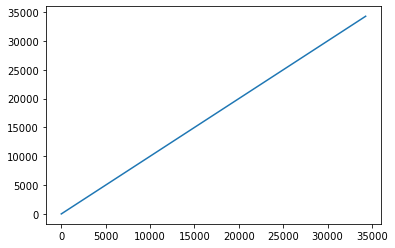

8.43590523046616e-11 -2.6852254075005637e-10 -1.2663998238273806 -72.5593650814199


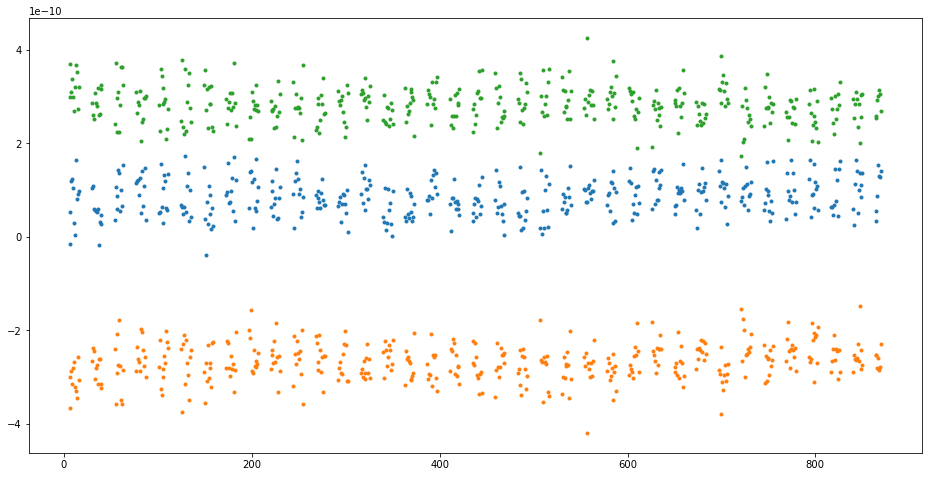

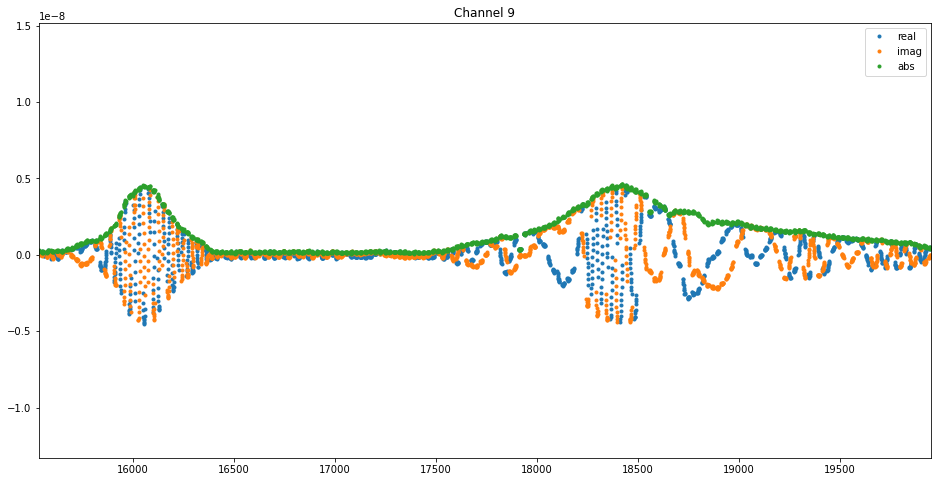

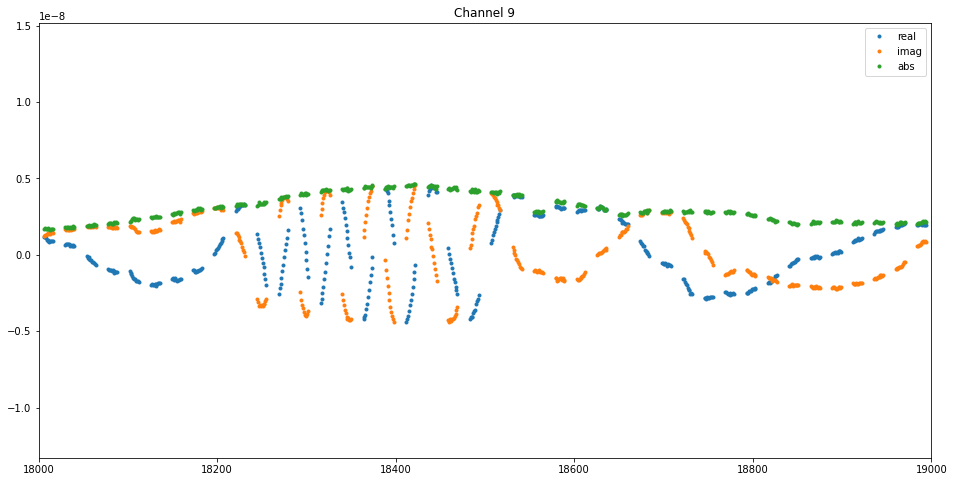

In [79]:
# lets subtract the mean real and imag (ie, subtract a phase) and see if that helps:

chind = 1 # reference
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind].real,'.',label='Real')
plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,chind].imag,'.',label='Imag')
plt.plot(concatdata.t_index[t_cut],np.abs(concatdata.V_cross[t_cut,f_ind,chind]),'.',label='abs')

plt.xlim(0,900)
plt.ylim(-2E-9,2E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

plt.plot(t_cut,concatdata.t_index[t_cut])
plt.show()

tempub = 400
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut[0:tempub]],concatdata.V_cross[t_cut[0:tempub],f_ind,chind].real,'.',label='Real')
plt.plot(concatdata.t_index[t_cut[0:tempub]],concatdata.V_cross[t_cut[0:tempub],f_ind,chind].imag,'.',label='Imag')
plt.plot(concatdata.t_index[t_cut[0:tempub]],np.abs(concatdata.V_cross[t_cut[0:tempub],f_ind,chind]),'.',label='abs')

realoff = np.median(concatdata.V_cross[t_cut[0:tempub],f_ind,chind].real)
imagoff = np.median(concatdata.V_cross[t_cut[0:tempub],f_ind,chind].imag)

realvis = concatdata.V_cross[t_cut,f_ind,1].real - realoff
imagvis = concatdata.V_cross[t_cut,f_ind,1].imag - imagoff
absvis = np.sqrt(realvis**2 + imagvis**2)

print(realoff, imagoff, np.arctan2(imagoff,realoff), np.degrees(np.arctan2(imagoff,realoff)))


fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],realvis,'.',label='real')
plt.plot(concatdata.t_index[t_cut],imagvis,'.',label='imag')
plt.plot(concatdata.t_index[t_cut],absvis,'.',label='abs')
plt.xlim(tclb,tcub)
plt.legend()
plt.title('Channel 9')
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[t_cut],realvis,'.',label='real')
plt.plot(concatdata.t_index[t_cut],imagvis,'.',label='imag')
plt.plot(concatdata.t_index[t_cut],absvis,'.',label='abs')
plt.xlim(18000,19000)
plt.legend()
plt.title('Channel 9')
plt.show()

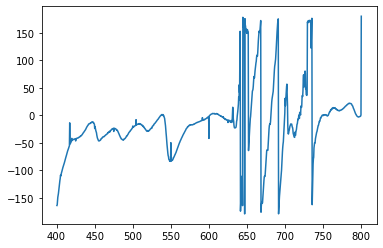

In [81]:
angles = np.zeros(len(freqs))

for f in np.arange(0,1024):
    realoff = np.median(concatdata.V_cross[t_cut[0:tempub],f,chind].real)
    imagoff = np.median(concatdata.V_cross[t_cut[0:tempub],f,chind].imag)

    realvis = concatdata.V_cross[t_cut,f_ind,1].real - realoff
    imagvis = concatdata.V_cross[t_cut,f_ind,1].imag - imagoff
    angles[f] = np.degrees(np.arctan2(imagoff,realoff))
plt.plot(freqs,angles)

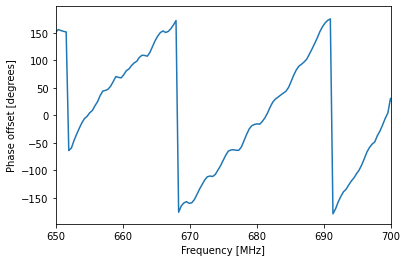

In [83]:
plt.plot(freqs,angles)
plt.xlim(650,700)
plt.ylabel('Phase offset [degrees]')
plt.xlabel('Frequency [MHz]')
plt.show()

Plotting waterfalls of autocorrelations
(15693, 130)


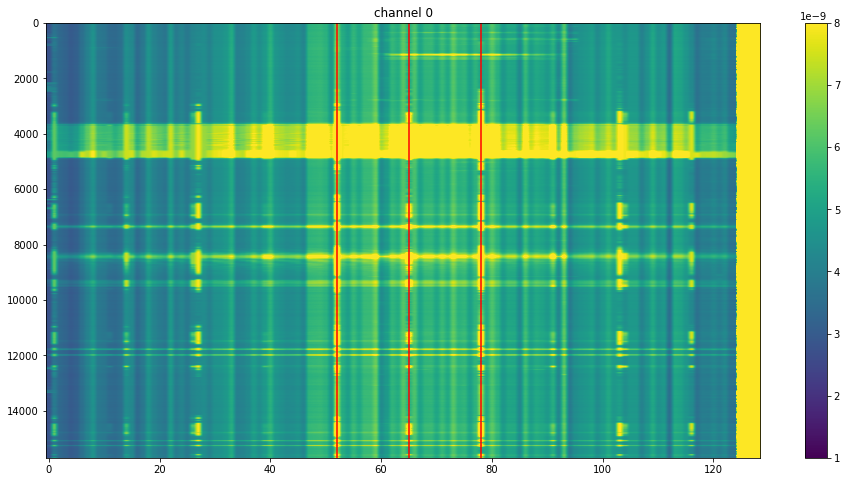

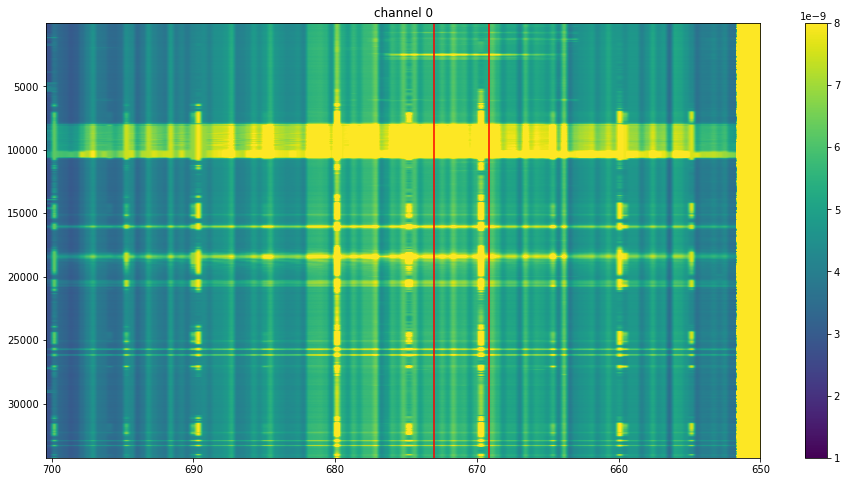

In [104]:
# waterfall of autos
print('Plotting waterfalls of autocorrelations')


#cmap = cm.jet
#cmap.set_bad('red') # Set NaNs to white

print(concatdata.V_cross[t_cut,255:385,0].shape)

j=0
vmin=1E-9
vmax=8E-9

fig=figure(figsize=(16,8))
plt.imshow(abs(concatdata.V_cross[t_cut,gfinds[0]:gfinds[-1],j]),vmin=vmin,vmax=vmax,aspect='auto')
#plt.xlim(tclb,tcub)
plt.title('channel '+str(j))
plt.colorbar()
plt.axvline(52,color='red')
plt.axvline(65,color='red')
plt.axvline(78,color='red')
plt.show()

fig=figure(figsize=(16,8))
plt.imshow(abs(concatdata.V_cross[t_cut,gfinds[0]:gfinds[-1],j]),vmin=vmin,vmax=vmax,aspect='auto',
           extent=[freqs[gfinds[0]],freqs[gfinds[-1]],t_cut[-1],t_cut[0]]) # left right bottom top
#plt.xlim(tclb,tcub)
plt.title('channel '+str(j))
plt.colorbar()
plt.axvline(673,color='red')
plt.axvline(669.17,color='red')
plt.show()


15693


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


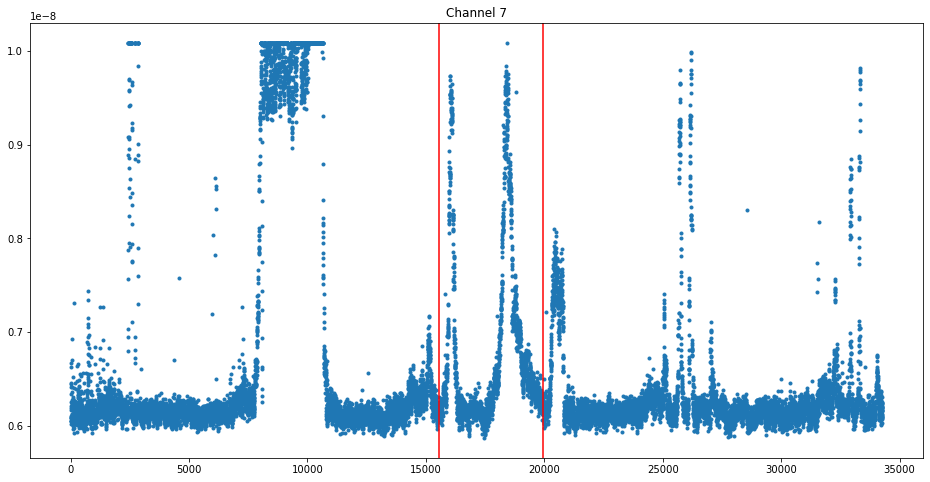

15693


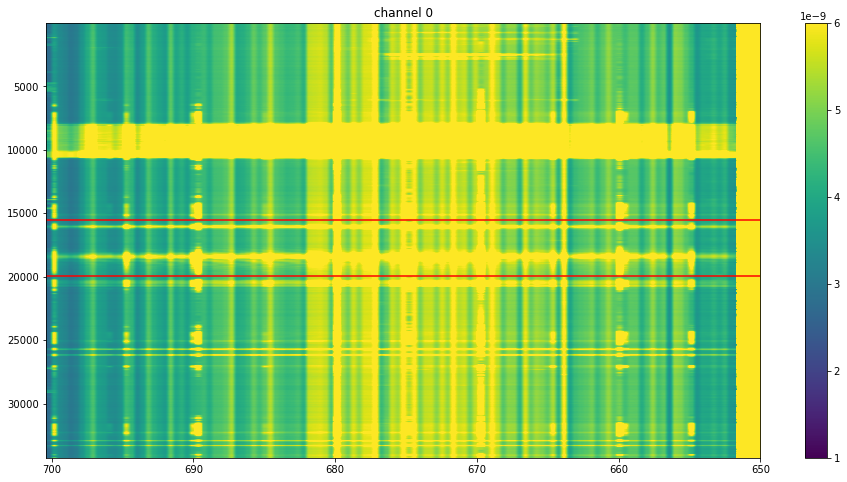

15693


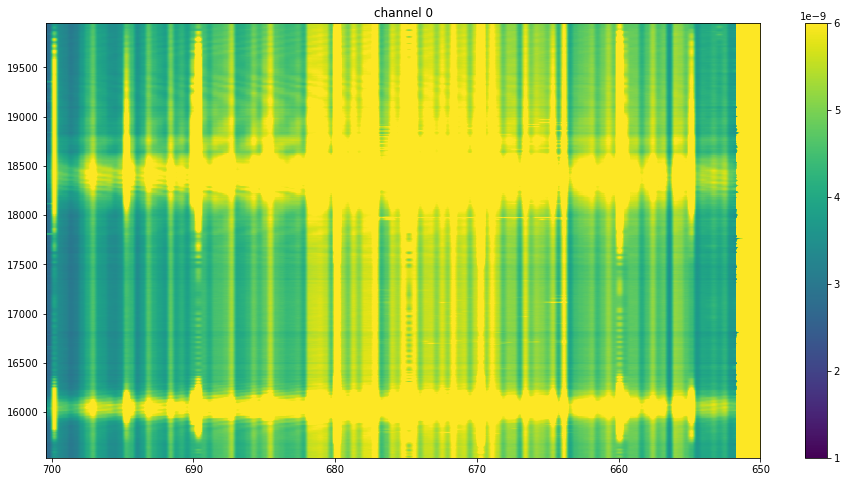

15693


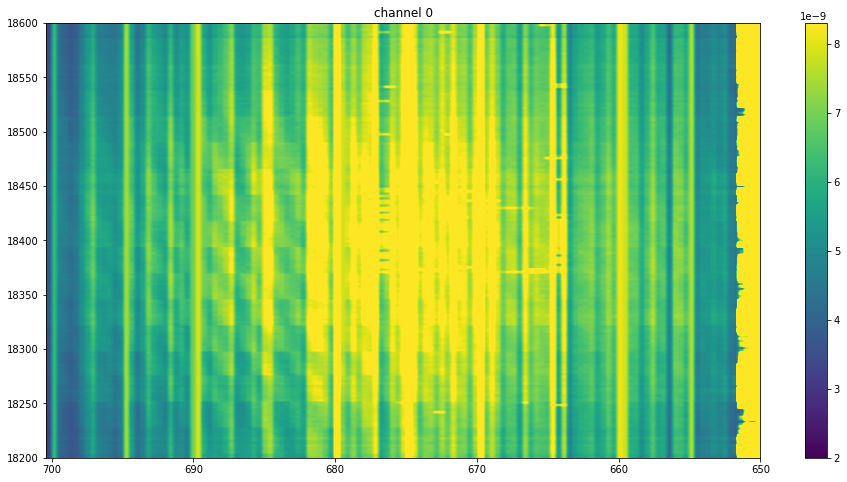

In [128]:
# colorbar to ignore that saturation
# zoom in on just the transit

print(len(t_cut))
f_ind=319
# autocorr
fig=figure(figsize=(16,8))
plt.plot(t_cut,concatdata.V_cross[t_cut,f_ind,0],'.')
plt.axvline(tclb,color='red')
plt.axvline(tcub,color='red')
plt.title('Channel 7')
plt.show()

j=0
vmin=1E-9
vmax=6E-9
print(len(t_cut))

fig=figure(figsize=(16,8))
plt.imshow(abs(concatdata.V_cross[t_cut,gfinds[0]:gfinds[-1],j]),vmin=vmin,vmax=vmax,aspect='auto',
          extent=[freqs[gfinds[0]],freqs[gfinds[-1]],t_cut[-1],t_cut[0]]) # left right bottom top
#plt.ylim(tclb,tcub)
plt.title('channel '+str(j))
plt.colorbar()
plt.axhline(tclb,color='red')
plt.axhline(tcub,color='red')
plt.show()


j=0
vmin=1E-9
vmax=6E-9
print(len(t_cut))

fig=figure(figsize=(16,8))
plt.imshow(abs(concatdata.V_cross[t_cut,gfinds[0]:gfinds[-1],j]),vmin=vmin,vmax=vmax,aspect='auto',
          extent=[freqs[gfinds[0]],freqs[gfinds[-1]],t_cut[-1],t_cut[0]]) # left right bottom top
plt.ylim(tclb,tcub)
plt.title('channel '+str(j))
plt.colorbar()
plt.show()




15693


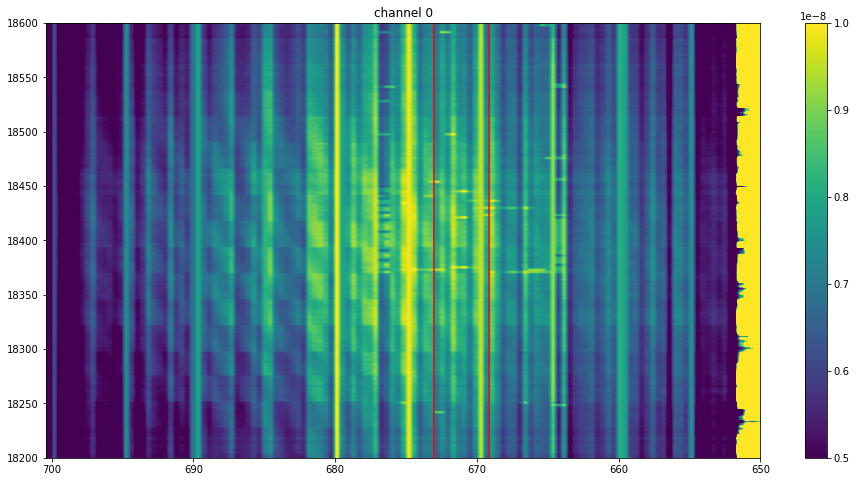

In [137]:
j=0
vmin=5E-9
vmax=1E-8
print(len(t_cut))

fig=figure(figsize=(16,8))
plt.imshow(abs(concatdata.V_cross[t_cut,gfinds[0]:gfinds[-1],j]),vmin=vmin,vmax=vmax,aspect='auto',
          extent=[freqs[gfinds[0]],freqs[gfinds[-1]],t_cut[-1],t_cut[0]]) # left right bottom top
plt.ylim(18200,18600)
plt.title('channel '+str(j))
plt.colorbar()
plt.axvline(673,color='red')
plt.axvline(669.17,color='red')
plt.show()

<ipython-input-37-d6018acce1f1>:7: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,j])),vmin=vmin,vmax=vmax,aspect='auto')


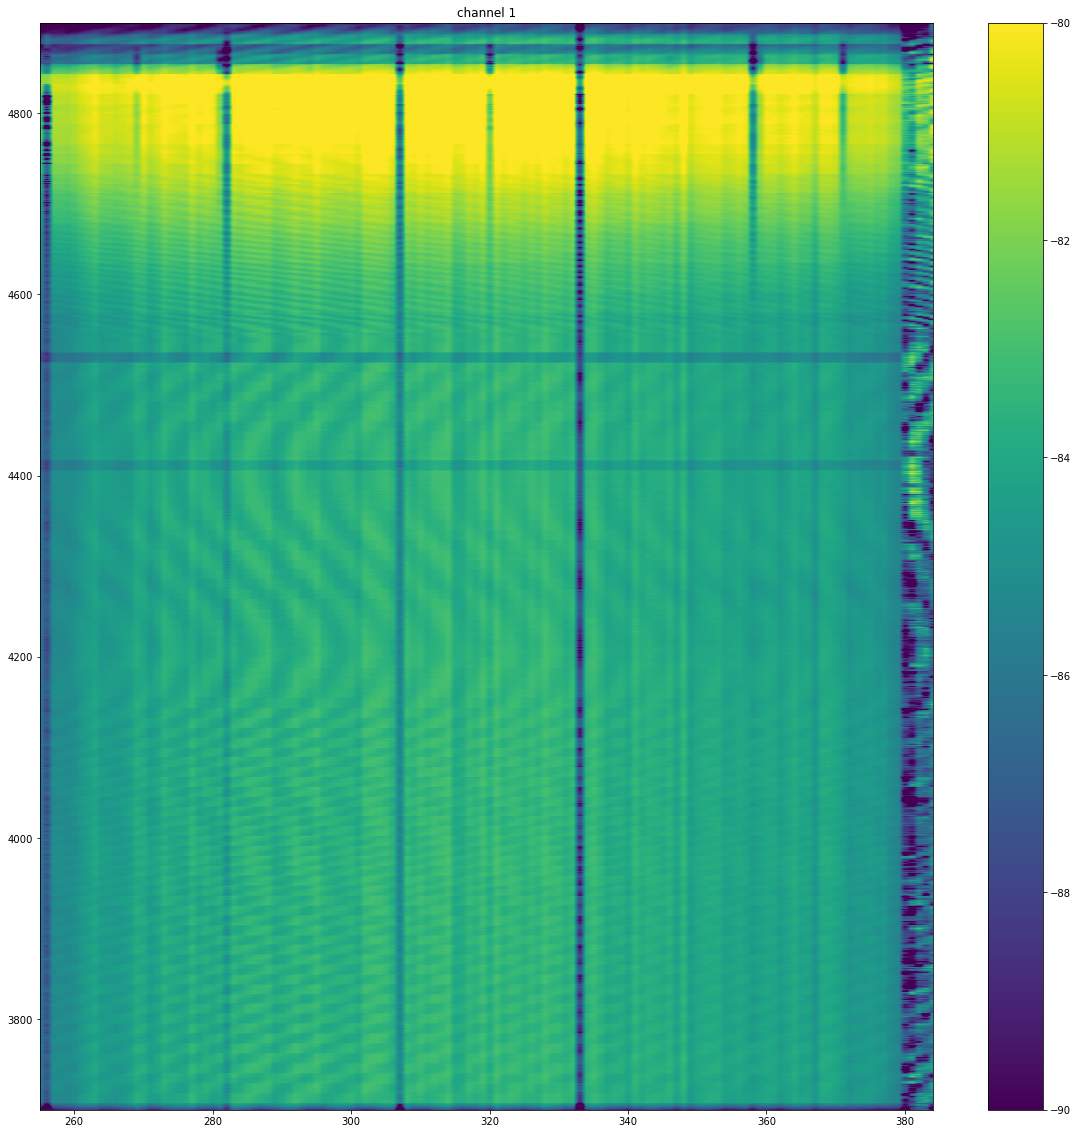

In [37]:
#print('plotting waterfalls for crosses')
## waterfall of crosses
vmin=-90
vmax=-80
j=1
fig=figure(figsize=(20,20))
plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,j])),vmin=vmin,vmax=vmax,aspect='auto')
plt.xlim(gfinds[0],gfinds[-1])
plt.ylim(3700,4900)
plt.title('channel '+str(j))
plt.colorbar()
plt.show()

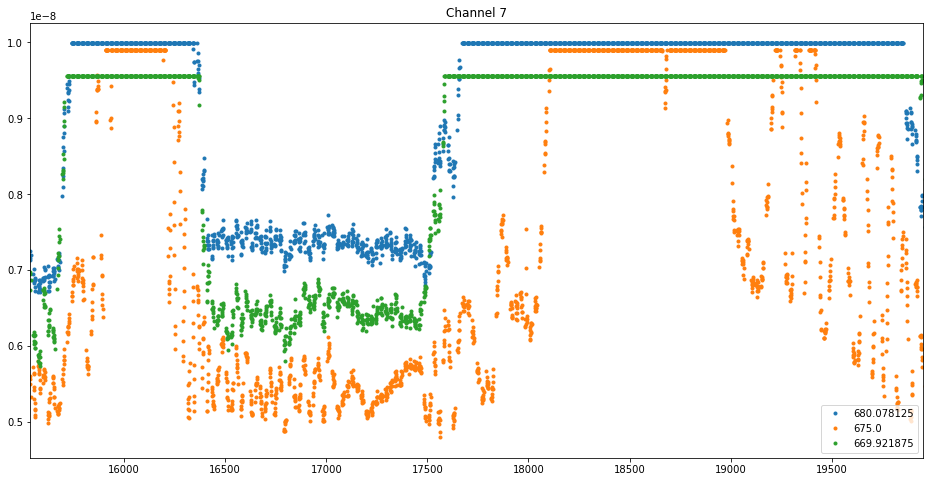

In [139]:
# lets examine line plots of those 10MHz blips
fig=figure(figsize=(16,8))

for f_add in [52,65,78]:
    f_ind = gfinds[0]+f_add
    # autocorr
    plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,0].real,'.',label=str(freqs[f_ind]))
    #plt.plot(concatdata.t_index[t_cut],concatdata.V_cross[t_cut,f_ind,0].imag,'.')
plt.xlim(tclb,tcub)
plt.legend()
plt.title('Channel 7')
plt.show()

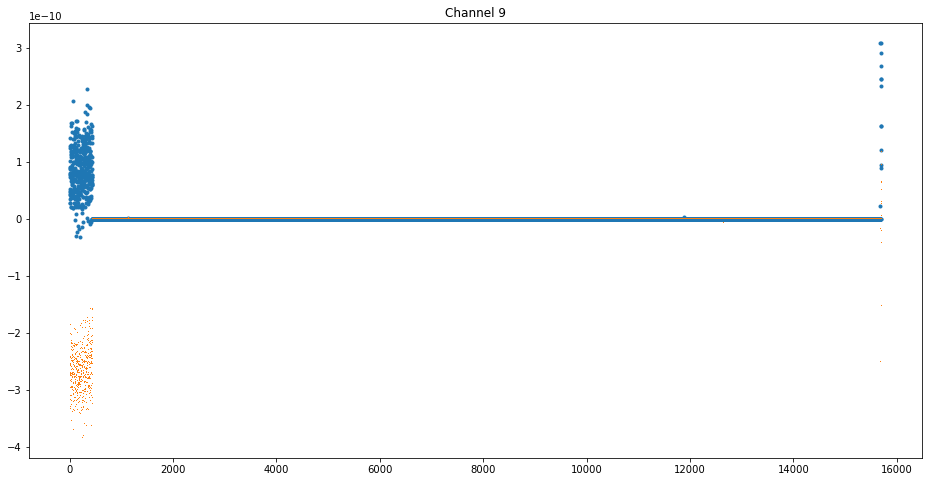

[2.66205733e-11 4.60635859e-11 7.95891544e-11 ... 9.42168414e-11
 0.00000000e+00 0.00000000e+00]


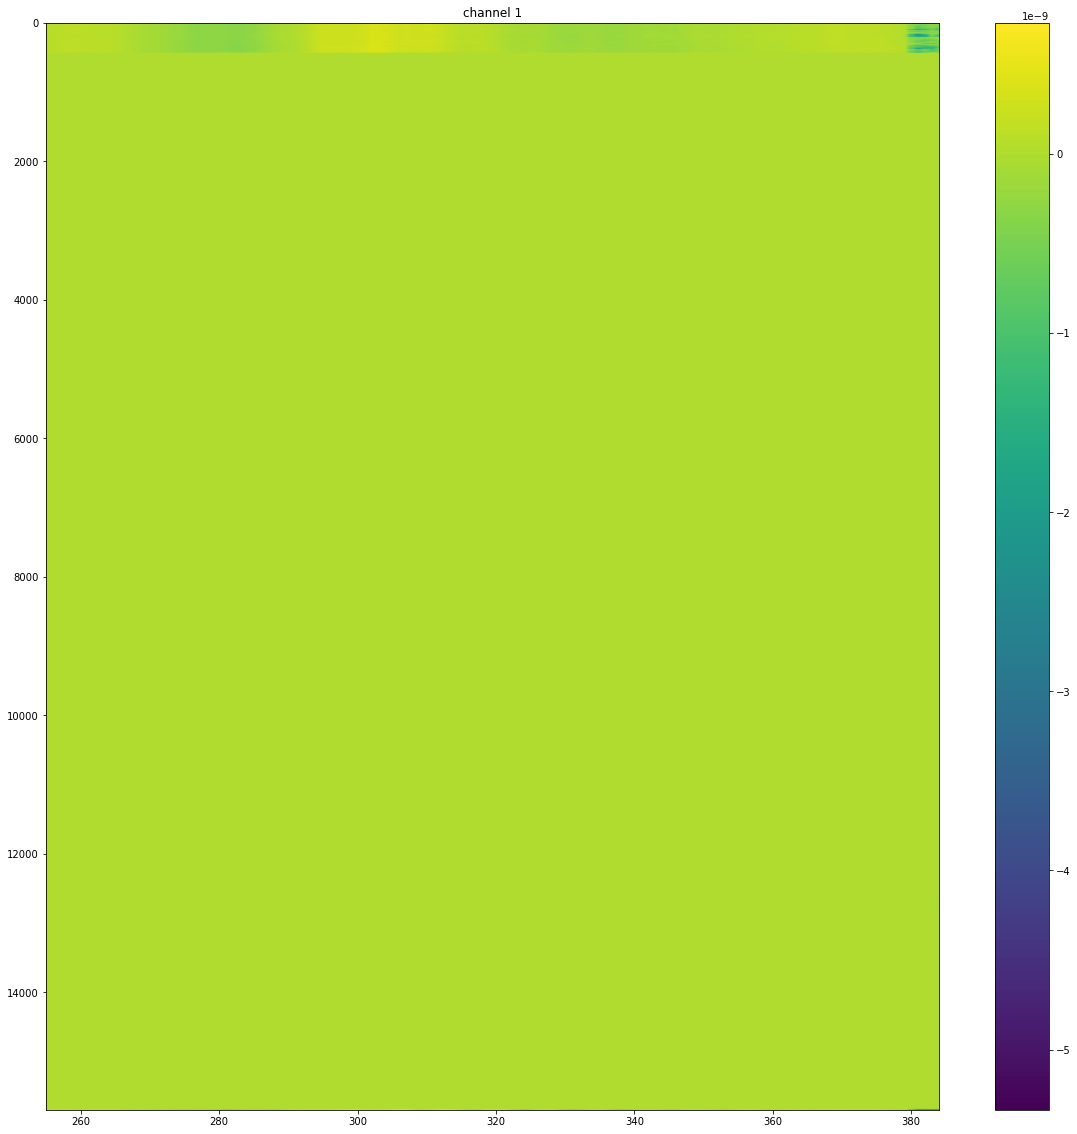

In [53]:
# plot off data

# crosscorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.V_cross[t_off,f_ind,1].real,'.')
plt.plot(concatdata.V_cross[t_off,f_ind,1].imag,',')
#plt.xlim(tclb,tcub)
#plt.ylim()
plt.title('Channel 9')
plt.show()

print(concatdata.V_cross[t_off,f_ind,1].real)

#print('plotting waterfalls for crosses')
## waterfall of crosses
vmin=-90
vmax=-80
j=1
fig=figure(figsize=(20,20))
plt.imshow(concatdata.V_cross[t_off,:,j].real,aspect='auto')
plt.xlim(gfinds[0],gfinds[-1])
#plt.ylim(3700,4900)
plt.title('channel '+str(j))
plt.colorbar()
plt.show()

In [39]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
concatdata.Perform_Background_Subtraction(window_size=7)



No handles with labels found to put in legend.


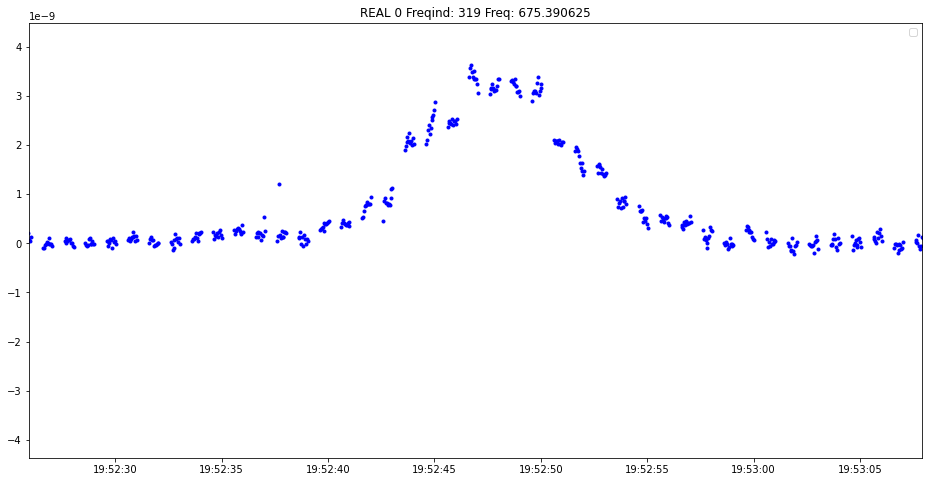

In [45]:
# look at the background subtracted data around transit

j=0

fig=figure(figsize=(16,8))
plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross_bgsub[t_cut,f_ind,j].real,'b.')
#plt.xlim(tclb,tcub)
plt.title('REAL '+str(j)+ ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
plt.xlim(concatdata.t_arr_datetime[tclb],concatdata.t_arr_datetime[tclb+1000])#concatdata.t_arr_datetime[tcub])
plt.legend()
plt.show()


In [ ]:
## Coordinates and indices fucked up????

In [ ]:
fig=figure(figsize=(16,8))

for i in np.arange(0.1E-9,0.4E-9,0.1E-9):

    newimag = concatdata.V_cross[:,f_ind,1].imag + i
    newabs = np.sqrt(concatdata.V_cross[:,f_ind,1].real**2 + newimag**2)


    #plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].real,',',label='Real')
    #plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].imag,',',label='imag')
    #plt.plot(concatdata.t_index[:],np.abs(concatdata.V_cross[:,f_ind,1]),',',label='ABS')
    #plt.plot(concatdata.t_index[:],newimag,'.',label='offsetimag')
    plt.plot(concatdata.t_index[:],newabs,'.',label='offsetABS '+str(i))

#plt.xlim(tclb,tcub)
plt.xlim(18200,19000)
#plt.xlim(15800,16500)
plt.ylim(0,5E-9)
#plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

In [ ]:
## Plotting angles and coordinates 

plt.plot(concatdata.t_index[i_st:i_end],concatdata.drone_xyz_LC_interp[i_st:i_end,0],label='x')
plt.plot(concatdata.t_index[i_st:i_end],concatdata.drone_xyz_LC_interp[i_st:i_end,1],label='y')
plt.plot(concatdata.t_index[i_st:i_end],
         np.degrees(np.arctan2(concatdata.drone_xyz_LC_interp[i_st:i_end,1],
                    concatdata.drone_xyz_LC_interp[i_st:i_end,2])),label='arctan r/y')
plt.legend()
plt.show()


plt.plot(concatdata.drone_rpt_interp[0:N,2],'r.',label='theta')
plt.plot(concatdata.drone_rpt_interp[0:N,1],'b.',label='phi')



thsign = np.zeros(len(concatdata.drone_rpt_interp[:,1]))
print(len(thsign))

for i in np.arange(len(thsign)):
    if np.degrees(concatdata.drone_rpt_interp[i,1]) < 180.0: thsign[i] = -1.0
    else: thsign[i] = 1.0
        
plt.plot(thsign,'b.')
plt.xlim(17000,22000)
plt.show()


# Lets fix the sign so theta can be negative
plt.plot(np.degrees(concatdata.drone_rpt_interp[:,2]),'b.',label='theta')
plt.plot(thsign)
plt.plot(np.degrees(thsign*concatdata.drone_rpt_interp[:,2]),'r.',label='sign fixed theta')
plt.legend()
#plt.ylim(-15,15)
plt.xlim(17000,22000)
plt.show()

# works!

In [ ]:
# crosscorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].real,'.')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].imag,'.')
#plt.xlim(tclb,tcub)
plt.title('Channel 9')
plt.show()

# crosscorr
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].real,'.')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].imag,'.')
plt.xlim(tclb,tcub)
plt.title('Channel 9')
plt.show()

plt.plot(concatdata.drone_xyz_LC_interp[:,0],label='x')
plt.legend()
plt.show()

In [ ]:
# before we go on, we should keep in mind that the correlator data has more time than the drone data
# the concat sets that non-drone time to nan

Theta = thsign*concatdata.drone_rpt_interp[:,2]
print(tclb, tcub)

plt.plot(Theta)
plt.axvline(17800,color='red')
plt.axvline(18600,color='red')
plt.show()

i_st = 17800
i_end = 18600

fig=figure(figsize=(16,8))
plt.plot(concatdata.V_cross[:,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(np.abs(concatdata.V_cross[:,f_ind,1]),'.',label='ABS')
plt.xlim(tclb,tcub)
plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.V_cross[:,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(np.abs(concatdata.V_cross[:,f_ind,1]),'.',label='ABS')
plt.xlim(tclb,tcub)
plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.xlim(i_st,i_end)
plt.legend()
plt.show()

In [ ]:









fig=figure(figsize=(16,8))
plt.plot(np.degrees(Theta),concatdata.V_cross[:,f_ind,1].real,'.',label='Real')
plt.plot(np.degrees(Theta),concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(np.degrees(Theta),
         np.abs(concatdata.V_cross[:,f_ind,1]),'.',label='ABS')
#plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.xlabel('PHI [deg]')
plt.legend()
plt.show()


plt.plot(Theta)
plt.axvline(19600,color='red')
plt.axvline(22000,color='red')
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.V_cross[:,1].real,'.',label='Real')
plt.plot(concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(np.abs(concatdata.V_cross[i_st:i_end,f_ind,1]),'.',label='ABS')
#plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.xlabel('PHI [deg]')
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
plt.plot(np.degrees(Theta[i_st:i_end]),concatdata.V_cross[i_st:i_end,f_ind,1].real,'.',label='Real')
plt.plot(np.degrees(Theta[i_st:i_end]),concatdata.V_cross[i_st:i_end,f_ind,1].imag,'.',label='imag')
plt.plot(np.degrees(Theta[i_st:i_end]),
         np.abs(concatdata.V_cross[i_st:i_end,f_ind,1]),'.',label='ABS')
#plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.xlabel('PHI [deg]')
plt.legend()
plt.show()

In [ ]:
# co pol
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].real,'.',label='Real')
plt.plot(concatdata.t_index[:],concatdata.V_cross[:,f_ind,1].imag,'.',label='imag')
plt.plot(concatdata.t_index[:],np.abs(concatdata.V_cross[:,f_ind,1]),'.',label='ABS')
plt.xlim(tclb,tcub)
plt.ylim(-5E-9,5E-9)
plt.title('1 m/s')
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
plt.plot(concatdata.t_index[:],np.angle(concatdata.V_cross[:,f_ind,1]),'.')
plt.xlim(tclb,tcub)
plt.title('Phase')
plt.show()


In [ ]:
p=1
plt.scatter(concattest0825.drone_xyz_LC_interp[t_cut,0],concattest0825.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concattest0825.V_bgsub[t_cut,f,p]),s=10.0,
            cmap='gnuplot2')
#plt.xlim(-40,40)
#plt.ylim(-40,40)
plt.colorbar()
plt.show()

In [ ]:
## OBJECTIVE 5C: concat Function: Synchronization_Function

## This function finds the absolute timing shift between the dji data from the drone and the correlator
    ## We will be loading t_delta_dji from the config file to save some time!
    ## This function only works if the source was pulsed and if V_bgsub was created using background subtraction.
    ## This function works by zooming into the gaussian main beam and removing saturated data points...
## To run, you must give the following:
    ## inputcorr  = the corr class used in the concat
    ## inputdrone = the drone class used in the concat
## The optional parameters and their default values are listed below:
    ## coarse_params=[-10.0,10.0,0.2]    = the min,max,step parameters for the coarse time offset array
    ## fine_params=[-0.5,0.5,0.01]       = the min,max,step parameters for the fine time offset array
    ## chans=np.arange(0,2)              = the channels to fit. 0,1 gives us each polarization
    ## freqs=np.arange(100,1024,150)     = the min,max,step parameters for the freq array axis
    ## FMB_coordbounds=[50.0,50.0,150.0] = the cartesian coords we restrict around the main beam
        # x within +/- 50m from dish center in Local Cartesian (LC)
        # y within +/- 50m from dish center in Local Cartesian (LC)
        # z > 150m from dish center in Local Cartesian (LC)
    ## FMB_ampbound=0.999                = amplitude percentile threshold for saturation... 
        # time indices where the amplitude exceeds 0.999*maximum value are excluded because they are saturated

concattest0825.Synchronization_Function(inputcorr=corrtest0825,inputdrone=dronetest0825,
                                        coarse_params=[-5.0,5.0,0.2],
                                        FMB_coordbounds=[30.0,30.0,150.0],
                                        FMB_ampbound=0.999)

## Since we are loading from the config, we get to skip an iterative loop and just take the solution and apply it.
    ## The verification plot shown is hidden when traceback==False is set in the concat initialization
    ## Look closely at the verification plots to see which channel appears to be the co-pol (channel 1)
    ## In the bottom 2 panels, compare the fit result (white gaussian) to the data points (in color)
        ## We are omitting the saturated points to find the REAL max value, instead of squashing our peak
        ## If we are satisfied with this fit, we should try to save the parameters we found...

In [ ]:
plt.scatter(concattest0825.drone_xyz_LC_interp[t_cut,0],concattest0825.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concattest0825.V_bgsub[t_cut,f,p]),s=10.0,
            cmap='gnuplot2')
#plt.xlim(-40,40)
#plt.ylim(-40,40)
plt.colorbar()
plt.show()

In [ ]:
concattest0825.Distance_Compensation(f_ind=900,plot_channels=[0])

In [ ]:
## OBJECTIVE 5D: concat Function: Export_yaml

## When we have results we want to save, we should export our results to a config file for future use:
    ## The file will be written to the directory stated when the concat class was initialized.
    ## If a concat config yaml file already exists, a new version will be saved.
## Uncomment this if you want to export a config file... 
concattest0825.Export_yaml()

In [ ]:
p=1
f = 896#768#896#832

for f in np.arange(512,1024,100):
    print(f)
    plt.scatter(concattest0825.drone_xyz_LC_interp[:,0],concattest0825.drone_xyz_LC_interp[:,1],
            c=10*np.log10(concattest0825.V[:,f,p]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.colorbar()
    plt.show()

#plt.hist(concattest0825.V[:,f,p],range=[-1E-11,1E-11],bins=100)
#plt.show()

In [ ]:
## OBJECTIVE 5E: concat Function: Main_Beam_Fitting

## Now we can do some analysis, since we have synchronized useful data. We can begin by fitting the main beam:
    ## You can specify the directory where you want the fit params to be output:
    ## fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/'
    ## This one sometimes takes a while, feel free to get a coffee or something.
concattest0825.Main_Beam_Fitting(fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/',
                                 FMB_ampbound=0.999,
                                 Vargs='bgsub')

In [ ]:
# copy and paste the file list above to make a plot
## this is your first glance at whether the Gaussian fits make sense across frequency for all channels
## these are grouped by polarization: small dots are one pol, big dots are the other
filelist=['FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz']
pu.plot_MBG_fits(filelist,cmp='gnuplot2')

In [ ]:
print(fits['G_popt'].shape)

In [ ]:
markers = ['s','v','^','>','P','x','+','o']
colors=['red','orange','yellow','green','blue','purple','pink']
import glob

fits = np.load('/hirax/GBO_Analysis_Outputs/main_beam_fits/FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz')
pols=[0,2,8,10,14]
freqs = np.arange(800,400,-400/1024)

# amp
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,0],markersize=4,color=colors[pp],label=str(p))
plt.title('Amplitude')
plt.legend()
plt.ylim(0,1.5E-7)
plt.show()

# X width
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,2],markersize=4,marker='.',color=colors[pp],linestyle='None',label=str(p))
plt.title('X width')
plt.legend()
plt.ylim(4,15)
plt.show()

# Y width
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,4],markersize=4,marker='.',linestyle='None',color=colors[pp],label=str(p))
plt.title('Y width')
plt.legend()
plt.ylim(4,17)
plt.show()

# X center
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,1],markersize=4,color=colors[pp],label=str(p))
plt.title('X center')
plt.legend()
#plt.ylim(4,14)
plt.show()

# Y center
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,3],markersize=4,color=colors[pp],label=str(p))
plt.title('Y center')
plt.legend()
#plt.ylim(4,14)
plt.show()


In [ ]:
# write out to a pickle file, name is autogenerated in the Smallify class

thingy = rc.Smallify(concattest0825)
print(thingy.tmppath)
with open(thingy.tmppath, 'wb') as outp:
    pickle.dump(thingy, outp, pickle.HIGHEST_PROTOCOL)
print('DONE')

In [ ]:
radfile = '/hirax/GBO_Analysis_Outputs/FLY625_20210826T182904Z_ver_20230905T125440_concat.pkl'
radfile = thingy.tmppath
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    ptest = pickle.load(inp)



In [ ]:

plt.scatter(ptest.drone_xyz_LC_interp[:,0],ptest.drone_xyz_LC_interp[:,1],c=10*np.log10(ptest.V_bgsub[:,900,p]), cmap='gnuplot2')

In [ ]:
print(len(ptest.V_bgsub[:,0,0]),len(ptest.V_bgsub[0,:,0]),len(ptest.V_bgsub[0,0,:]))
print(len(ptest.V_bg[:,0,0]),len(ptest.V_bg[0,:,0]),len(ptest.V_bg[0,0,:]))

In [ ]:
## let's try some operations to save it

# write a reduced class
[a for a in dir(ptest) if not a.startswith('__')] # prints out all attrs

In [ ]:
################################################
################# DEPRECATED ###################
################################################
##### Below is deprcated, keep as a record #####
################################################
################# DEPRECATED ###################
################################################
#
## Checking if the flight and numbers correspond from what I've written in the spreadsheet#
#
## 1. You will want to exclude regions of the flight that contain the drone moving to/from home.
### a. read the whole file in (tlb, tub to 0,-1)
### b. read in the flight
### c. plot (I suggest in a separate cell) the flight, examine with various tlb, tub bounds until you've 
###    excluded the stuff you don't want
### d. copy the tlb, tub into a vector under the flight for posterity [someday, a yaml, but not today]
### e. read in the drone file again, this time setting the tlb, tub to something
### this last step is crucial, there isn't a better way to restrict the rest of the analysis/pickling afterwards
#
#[tlb,tub]=[0,-1] # default values to read in full array
#
#config_directory="/hirax/GBO_Analysis_Outputs/concat_config_files/"
#tclb,tcub=[8500,20000]
#
#
##fly = '533'
##cdat= '20210826T182904Z'
##[tlb,tub]=[1900,11000]
#
##fly = '534'
##cdat = '20210826T185621Z'
##[tlb,tub]=[1650,10000]
#
##fly = '535'
##cdat = '20210826T192056Z'
##[tlb,tub]=[2000,9500]
#
##fly = '536' # this flight, careful to read in only corr files 0-95
##cdat = '20210826T195003Z'
##[tlb,tub]=[1600,10100]
#
##fly='613'
##cdat='20211021T144905Z'
##[tlb,tub]=[5300,13800]
#
##fly = '615'
##cdat = '20211021T151650Z'
##[tlb,tub]=[3200,10600]
#
##fly = '618'
##cdat = '20211021T183430Z'
##[tlb,tub]=[7300,15000]
#
##fly = '619'
##cdat = '20211021T185805Z'
##[tlb,tub]=[3000,11400]
#
##fly = '620'
##cdat = '20211021T192212Z'
##[tlb,tub]=[1550,9400]
#
##fly = '623'
##cdat = '20211021T203206Z'
##[tlb,tub]=[1700,9500]
#
##fly = '624'
##cdat = '20211021T205659Z'
##[tlb,tub]=[2400,10200]
#
##fly = '625'
##cdat = '20211021T214028Z'
##[tlb,tub]=[2900,12000]
#
##fly = '646'
##cdat = '20211022T183659Z'
##[tlb,tub]=[7500,16100]
#
##fly = '647'
##cdat = '20211022T185749Z'
##[tlb,tub]= [1600,10400]
#
##fly = '648'
##cdat = '20211022T191922Z'
##[tlb,tub]=[2700,10700]
#
##fly = '649'
##cdat = '20211022T194308Z'
##[tlb,tub]=[1500,9900]
#
#if int(fly) < 537:
#    mdir='/hirax/GBO_Aug_2021/TONE_ACQ/'+cdat+'_yale_drone/corr/' # August 2021
#    gaindir='/hirax/GBO_Aug_2021/TONE_ACQ/digital_gains/'+cdat+'_yale_drone_yale_digitalgain/' # August 2021
#else:
#    mdir='/hirax/GBO_Oct_2021/TONE_ACQ/'+cdat+'_yale_drone/corr/' # Oct 2021
#    gaindir='/hirax/GBO_Oct_2021/TONE_ACQ/digital_gains/'+cdat+'_yale_drone_yale_digitalgain/' # Oct 2021
#
#sdir = os.listdir(mdir)[0]
#datadir=mdir+sdir+'/'
#print(sdir, datadir,gaindir)
#    
#dronedir='/hirax/all_drone_data/datcon_csv/'
#dronetest0825=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='FLY'+fly+'.csv',site_class=gbosite,tlb=tlb,tub=tub)
#
#print('DONE reading in drone data')
#print(dronetest0825.t_arr_datetime[0], dronetest0825.t_arr_datetime[-1])
#
################################################
################# DEPRECATED ###################
################################################
##### Above is deprcated, keep as a record #####
################################################
################# DEPRECATED ###################
################################################
